# 🍷 Wine Quality Prediction

**Objective:** Train and compare three classification models to predict the quality
score of wine (scale 3–8, plus a rare 9 in the white set) from its physicochemical
properties (acidity, density, alcohol content, etc.).

**Dataset:** UCI Machine Learning Repository — *Wine Quality* (Cortez et al., 2009).
Two files: `winequality-red.csv` (1,599 samples) and `winequality-white.csv` (4,898 samples),
each with 11 physicochemical features + 1 `quality` target.

**Tech stack:** Python · pandas · numpy · scikit-learn (RandomForest, SGD, SVC) · seaborn · matplotlib

**Workflow**
1. Load & inspect structure, class distribution
2. EDA — feature distributions + correlation heatmap
3. Class-imbalance discussion
4. Feature engineering — binned binary / 3-class targets
5. Stratified train/test split
6. Train Random Forest, SGD, SVC
7. Evaluate — accuracy, classification report, confusion matrix
8. Random-Forest feature importance
9. Side-by-side comparison table
10. Conclusion & deployment recommendation

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    ConfusionMatrixDisplay,
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
import sklearn
print("sklearn   ", sklearn.__version__)

numpy      2.5.3
pandas     3.0.5
sklearn    1.9.1


## 1. Load the dataset & inspect structure

We load both files, tag each row with its `wine_type`, and concatenate them into a
single frame. Working with the combined 6,497-row dataset gives more data to learn
from and lets us keep `wine_type` as an informative feature (red vs. white wines
differ noticeably in density, residual sugar and alcohol).

In [2]:
red = pd.read_csv("data/winequality-red.csv", sep=";")
white = pd.read_csv("data/winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)
print("Combined shape:", df.shape)
df.head()

Combined shape: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
# Structure overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
# Missing values & duplicates
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

Duplicate rows: 1177


The data is clean: **no missing values**. There are some duplicate rows (identical
physicochemical readings), which is plausible for real wines that share a measured
profile; we keep them because they represent genuinely repeated measurements.

### Class distribution of the target (`quality`)

In [6]:
quality_counts = df["quality"].value_counts().sort_index()
print(quality_counts)
print("\nProportions (%):")
print((quality_counts / len(df) * 100).round(2))

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Proportions (%):
quality
3     0.46
4     3.32
5    32.91
6    43.65
7    16.61
8     2.97
9     0.08
Name: count, dtype: float64


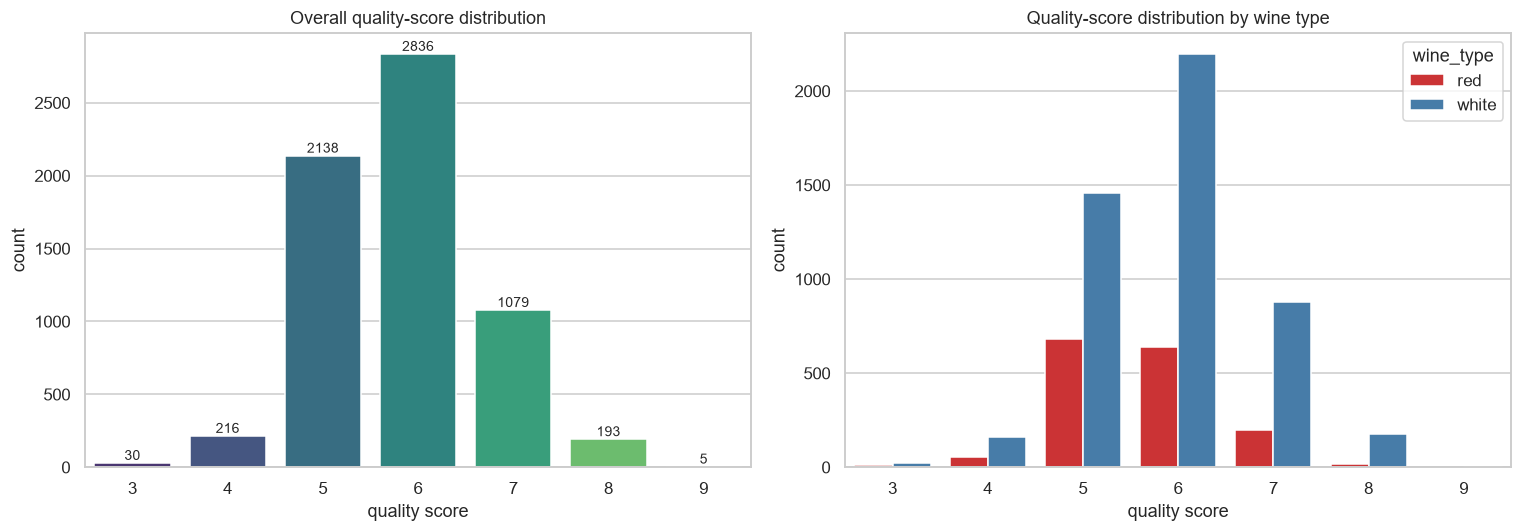

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
sns.countplot(data=df, x="quality", ax=axes[0], palette="viridis")
axes[0].set_title("Overall quality-score distribution")
axes[0].set_xlabel("quality score")
axes[0].set_ylabel("count")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

# By wine type
sns.countplot(data=df, x="quality", hue="wine_type", ax=axes[1], palette="Set1")
axes[1].set_title("Quality-score distribution by wine type")
axes[1].set_xlabel("quality score")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig("figures/01_quality_distribution.png", bbox_inches="tight")
plt.show()

## 2. Exploratory Data Analysis

### 2.1 Distribution of every chemical feature

We plot a histogram + KDE for each of the 11 physicochemical features, split by
wine type, to understand shape, skew and outliers.

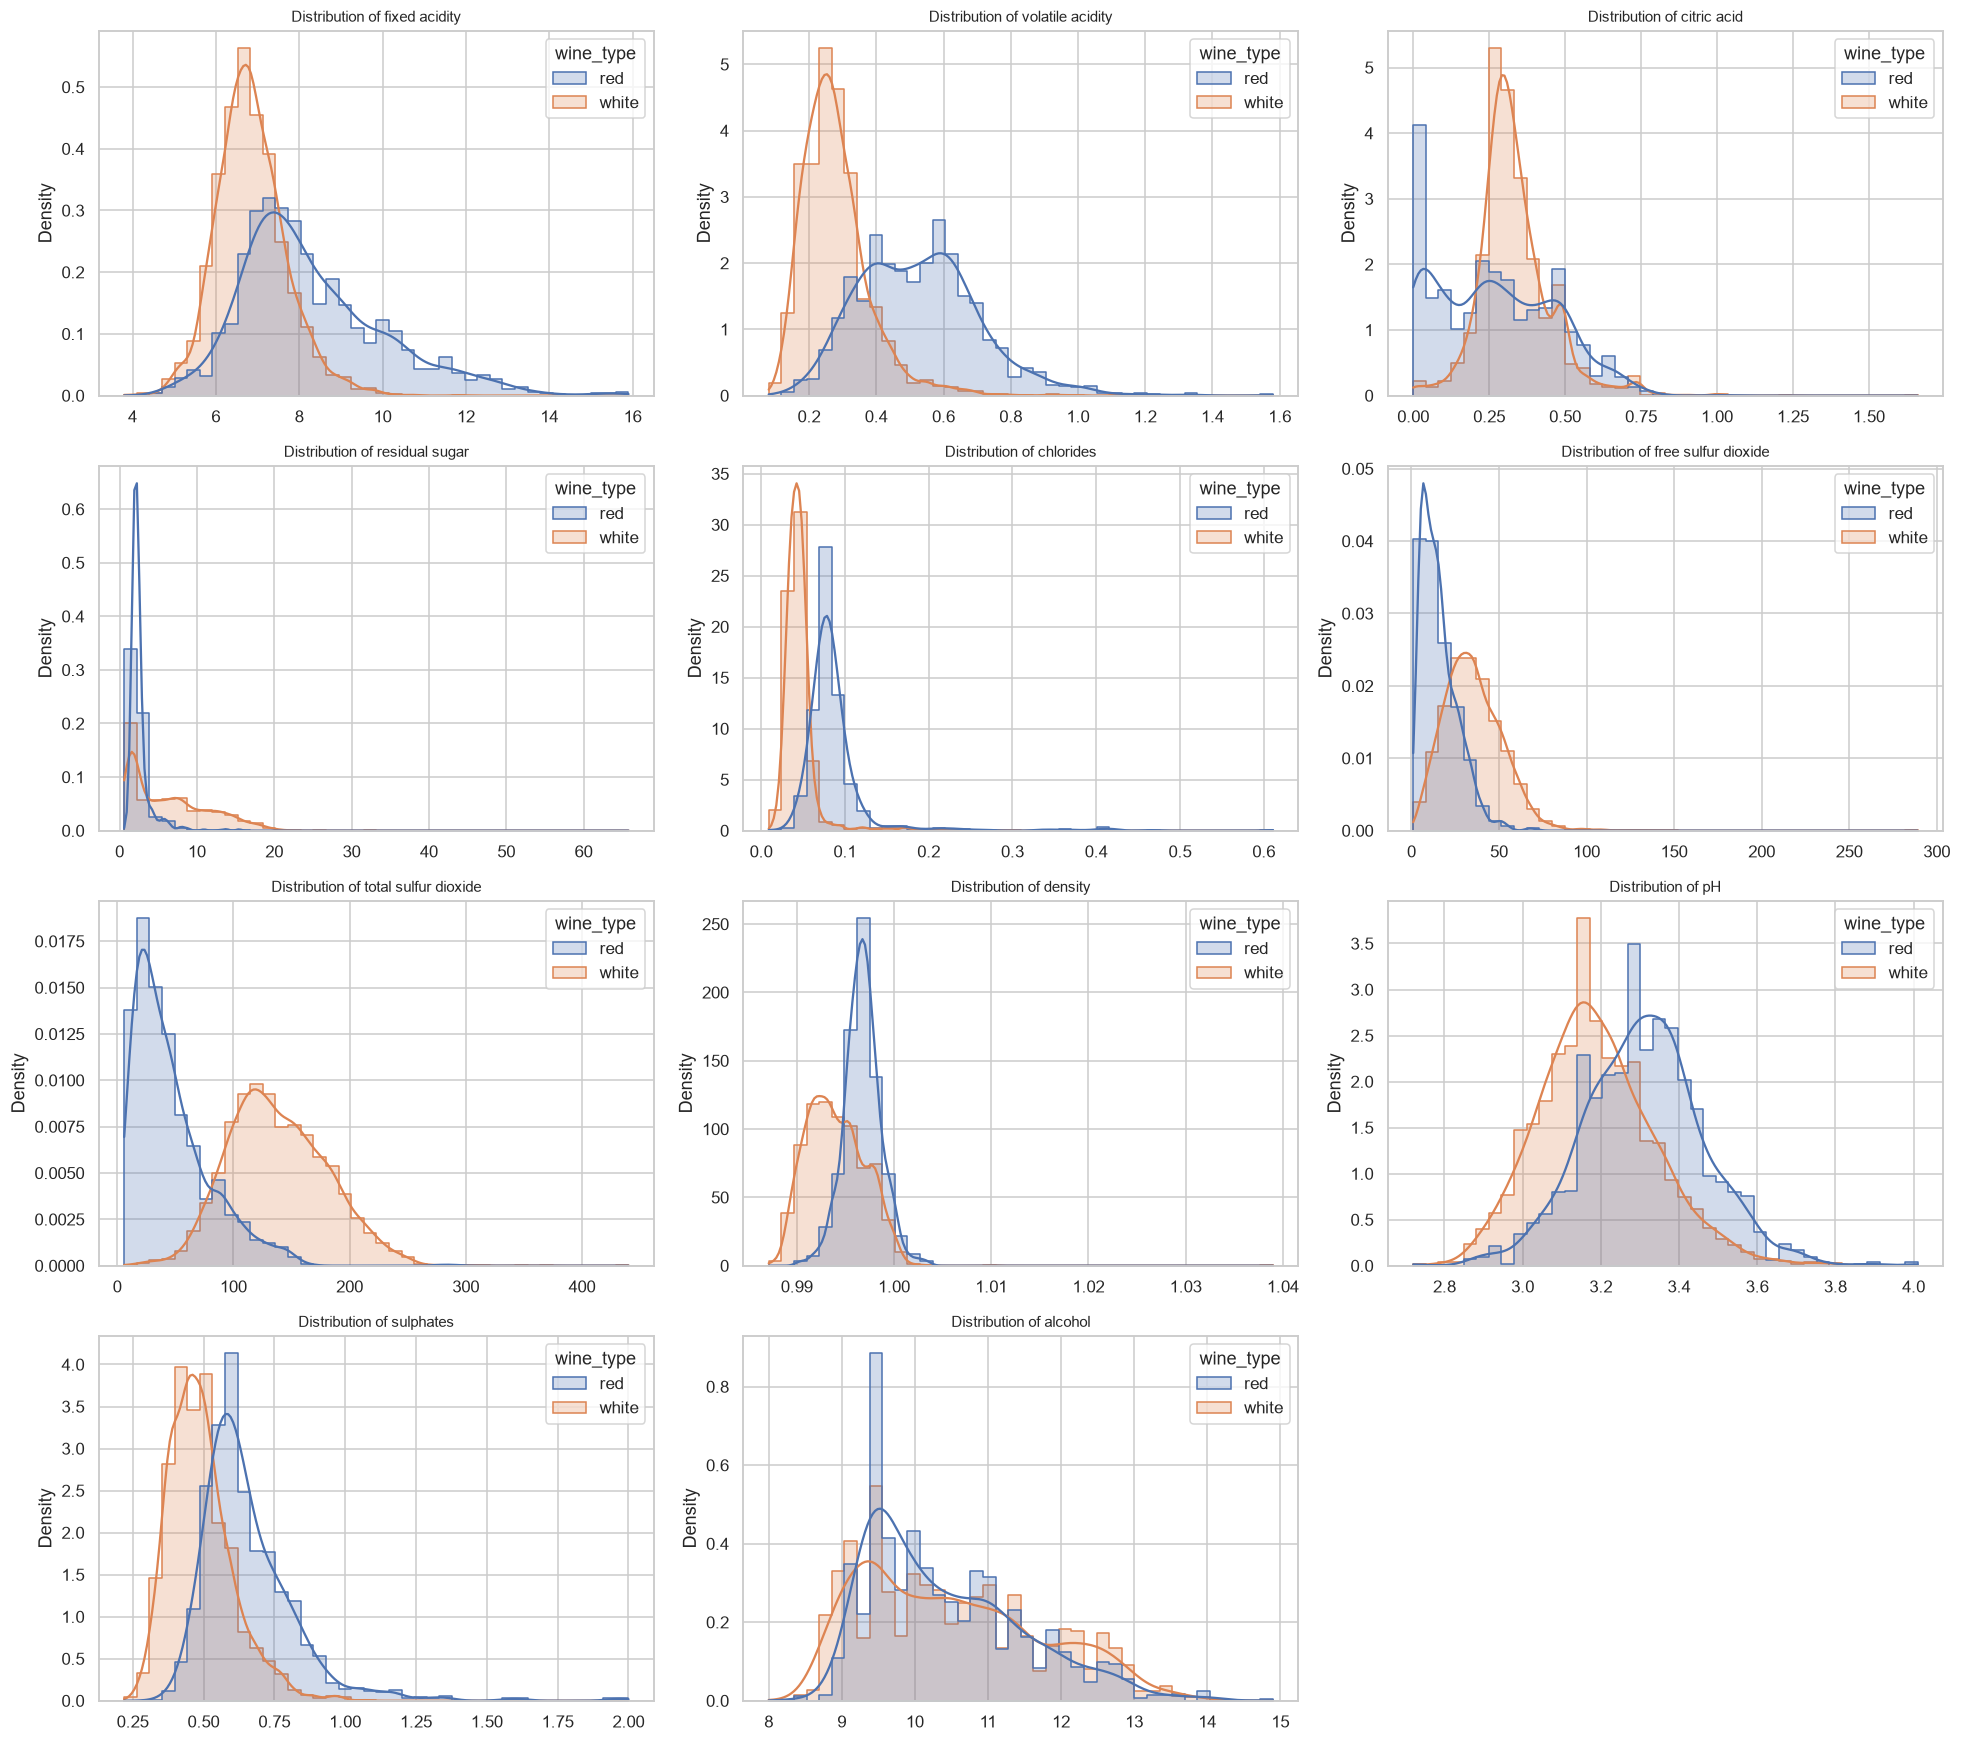

In [8]:
num_features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    sns.histplot(data=df, x=feat, hue="wine_type", bins=40, kde=True,
                 ax=axes[i], element="step", stat="density", common_norm=False)
    axes[i].set_title(f"Distribution of {feat}", fontsize=10)
    axes[i].set_xlabel("")
# Remove the empty 12th subplot
fig.delaxes(axes[len(num_features)])
plt.tight_layout()
plt.savefig("figures/02_feature_distributions.png", bbox_inches="tight")
plt.show()

**Observations**
- `residual sugar`, `chlorides`, `sulphates` (and to a degree `volatile acidity`) are
  strongly **right-skewed** — a few large values create long tails.
- **Red vs. white separation is visible**: white wines have much higher `residual sugar`
  and `total sulfur dioxide`, while red wines have higher `volatile acidity` and `density`.
- `pH`, `density` and `alcohol` are closer to symmetric.
- Because features live on very different scales (e.g. `total sulfur dioxide` up to ~300 vs.
  `chlorides` ~0.1), **distance-based / gradient-based models (SVC, SGD) will need scaling**.

### 2.2 Correlation heatmap

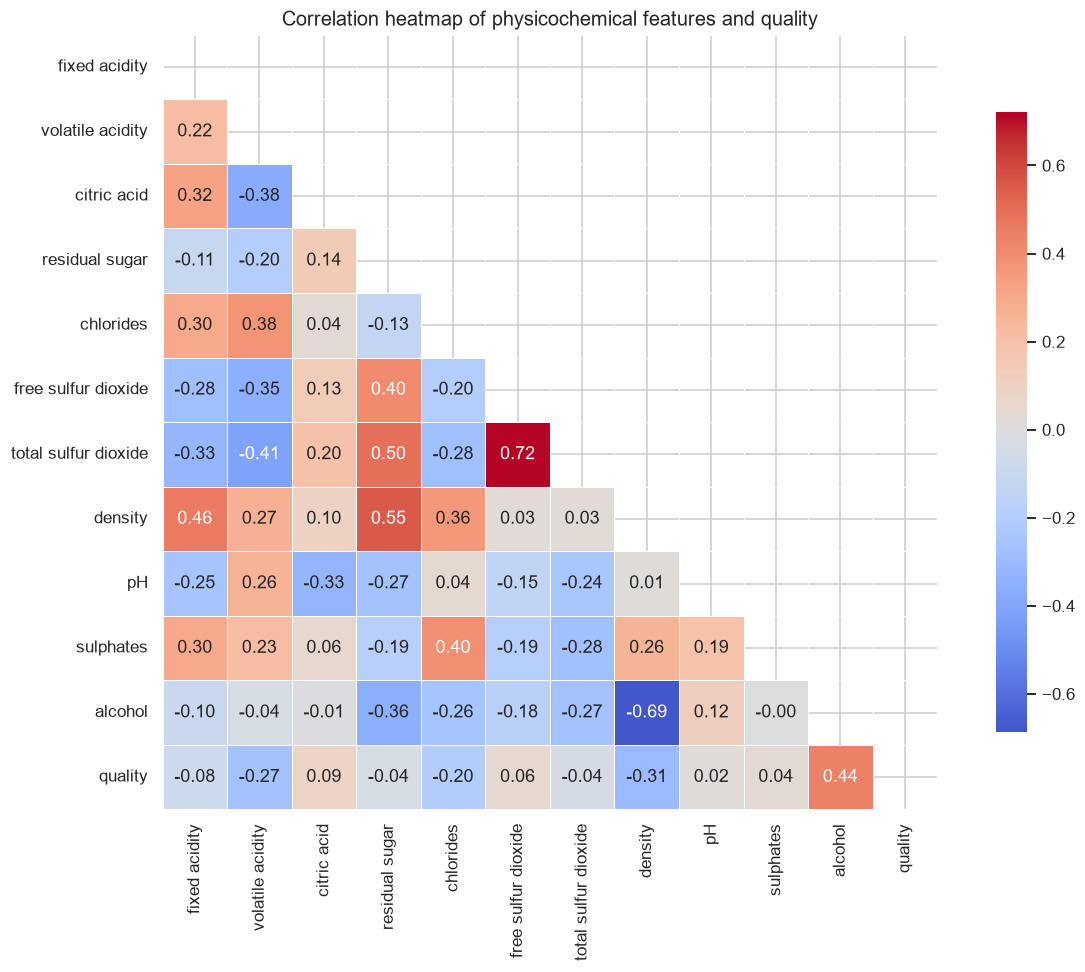

In [9]:
plt.figure(figsize=(12, 9))
corr = df[num_features + ["quality"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of physicochemical features and quality", fontsize=13)
plt.tight_layout()
plt.savefig("figures/03_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### 2.3 Correlation with the target

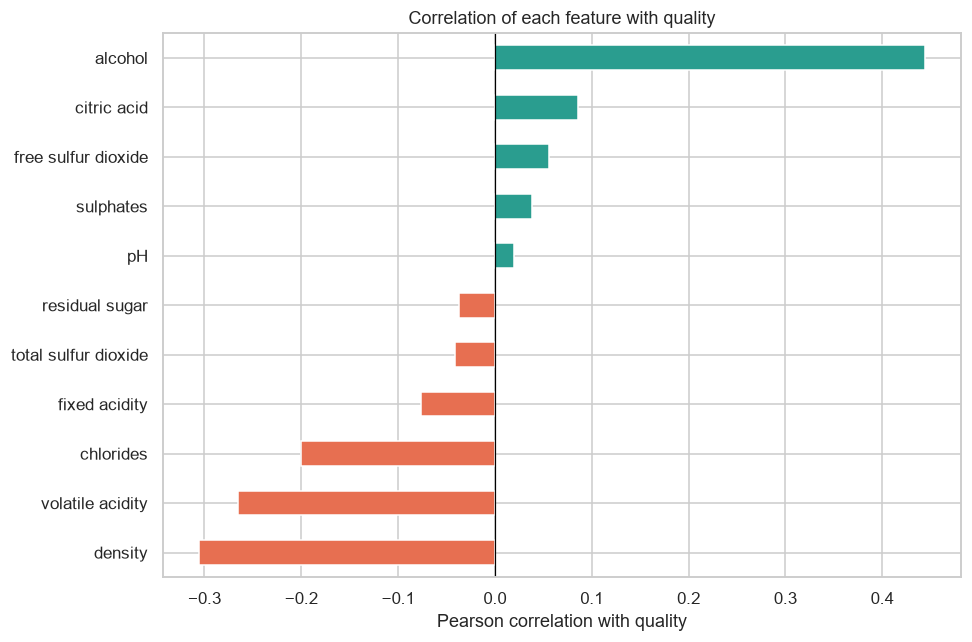

In [10]:
target_corr = corr["quality"].drop("quality").sort_values()
plt.figure(figsize=(9, 6))
target_corr.plot(kind="barh", color=(target_corr > 0).map({True: "#2a9d8f", False: "#e76f51"}))
plt.title("Correlation of each feature with quality")
plt.xlabel("Pearson correlation with quality")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("figures/04_correlation_with_target.png", bbox_inches="tight")
plt.show()

**Key correlations with `quality`:**
- **Positive:** `alcohol` (~+0.44), `sulphates`, `citric acid`, `fixed acidity`
- **Negative:** `volatile acidity` (~−0.27), `density`, `chlorides`, `total sulfur dioxide`

`alcohol` is the single strongest linear predictor. `density` and `alcohol` are themselves
strongly negatively correlated (alcohol lowers density), so there is some **multicollinearity**
— tree models cope well with this, linear/distance models less so.

### 2.4 Boxplots: how features vary across quality scores

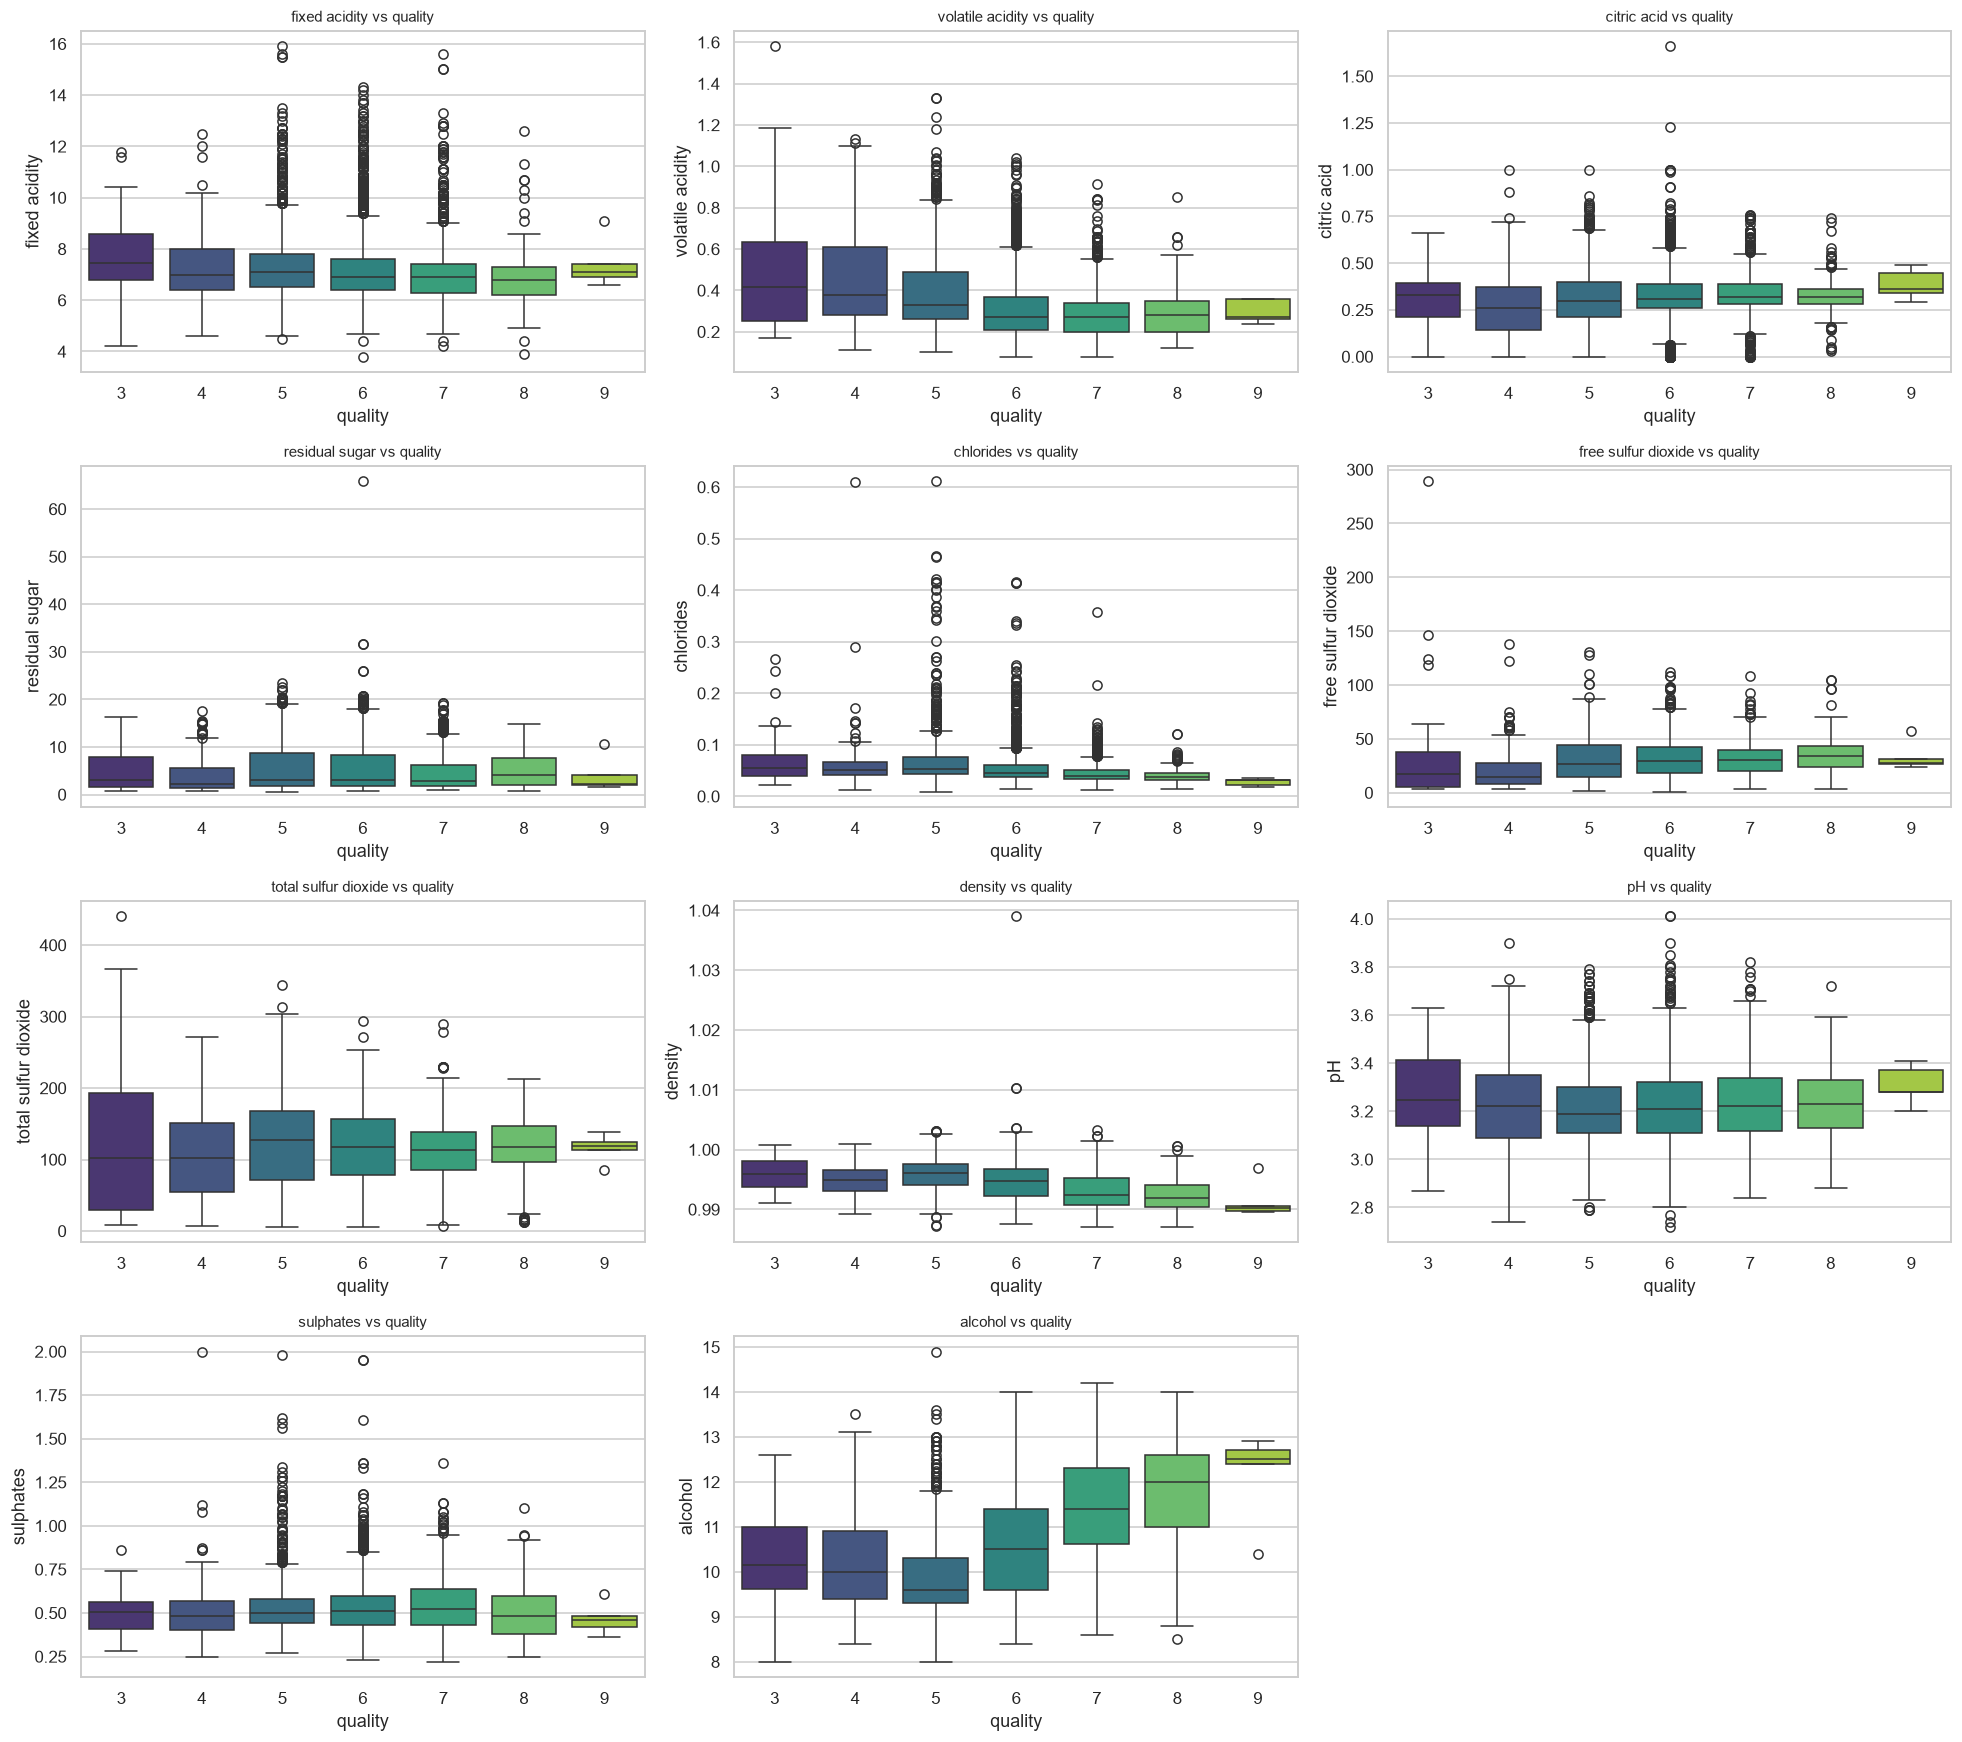

In [11]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
for i, feat in enumerate(num_features):
    sns.boxplot(data=df, x="quality", y=feat, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{feat} vs quality", fontsize=10)
fig.delaxes(axes[len(num_features)])
plt.tight_layout()
plt.savefig("figures/05_feature_boxplots_by_quality.png", bbox_inches="tight")
plt.show()

Higher-quality wines trend toward **more alcohol**, **higher sulphates**, **lower volatile
acidity** and **lower density**. The trend is monotonic for alcohol, which is why it dominates
even simple models.

## 3. Class imbalance — discussion

Looking at the counts above:

| quality | count | % of data |
|--------:|------:|----------:|
| 3 | ~30 | ~0.5% |
| 4 | ~216 | ~3.3% |
| 5 | ~2138 | ~33% |
| 6 | ~2836 | ~44% |
| 7 | ~1079 | ~17% |
| 8 | ~193 | ~3.0% |
| 9 | ~5 | ~0.08% |

**The target is severely imbalanced.** Scores 5 and 6 make up ~77% of all samples,
while scores 3, 4, 8 and 9 are rare (together < 7%). This has concrete modelling consequences:

1. **Accuracy is a misleading metric.** A trivial model that always predicts "6"
   already scores ~44% accuracy yet learns nothing.
2. **Rare classes are ignored.** With only ~5 samples of quality 9, a stratified split
   leaves ~1 test sample — no model can learn or be fairly evaluated on that class.
3. **Stratified splitting is essential** so that every split (and CV fold) sees a
   representative mix of classes. We use `stratify=y` in `train_test_split`.
4. **Model bias toward the majority.** Classifiers optimise overall loss and will
   under-predict minority scores. Remedies: `class_weight="balanced"`, resampling
   (SMOTE / undersampling), or **grouping the target** so each class has enough support.

**Our decision:** We report *macro F1* (which weights every class equally) alongside
accuracy, and we prefer a **grouped target** to give the model learnable, balanced-ish classes.

## 4. Feature engineering — binned targets

We engineer two alternative targets and evaluate the trade-off:

**A. Binary (good / bad)** — `quality >= 7` → *good (1)*, else *bad (0)*.
- Rationale: wine specialists treat a score of 7+ as "good/varietal quality".
- Produces a cleaner but still imbalanced problem (~17% good).
- Best when the business question is a **thumbs-up / thumbs-down gate**.

**B. Three-class (low / medium / high)**:
- `quality <= 5` → **low**, `quality in {6,7}` → **medium**, `quality >= 8` → **high**.
- Rationale: preserves ordinality, keeps three meaningful tiers while merging the
  tiny extremes into the classes that border them (score 3/4 join "low", score 9 joins "high").
- Better class balance than the raw 7-class problem, and more informative than binary.

**Which do we choose?** We train the three models on the **3-class target** as the primary
task (it keeps more information and is the more realistic "predict a quality tier" use-case),
and we also demonstrate the binary target for comparison. We justify: 3-class avoids the
5-sample class-9 problem entirely, keeps a usable amount of data per class, and still
lets the model distinguish genuinely different wine tiers.

In [12]:
# --- Binary target: good (>=7) vs bad ---
df["quality_binary"] = (df["quality"] >= 7).astype(int)

# --- 3-class target: low (<=5) / medium (6-7) / high (>=8) ---
def to_three_class(q):
    if q <= 5:
        return "low"
    elif q <= 7:
        return "medium"
    else:
        return "high"

df["quality_3class"] = df["quality"].apply(to_three_class)

print("Binary target distribution:")
print(df["quality_binary"].value_counts().rename({0: "bad (<7)", 1: "good (>=7)"}))
print()
print("3-class target distribution:")
order = ["low", "medium", "high"]
print(df["quality_3class"].value_counts().reindex(order))
print()
print("3-class proportions (%):")
print((df["quality_3class"].value_counts(normalize=True).reindex(order) * 100).round(2))

Binary target distribution:
quality_binary
bad (<7)      5220
good (>=7)    1277
Name: count, dtype: int64

3-class target distribution:
quality_3class
low       2384
medium    3915
high       198
Name: count, dtype: int64

3-class proportions (%):
quality_3class
low       36.69
medium    60.26
high       3.05
Name: proportion, dtype: float64


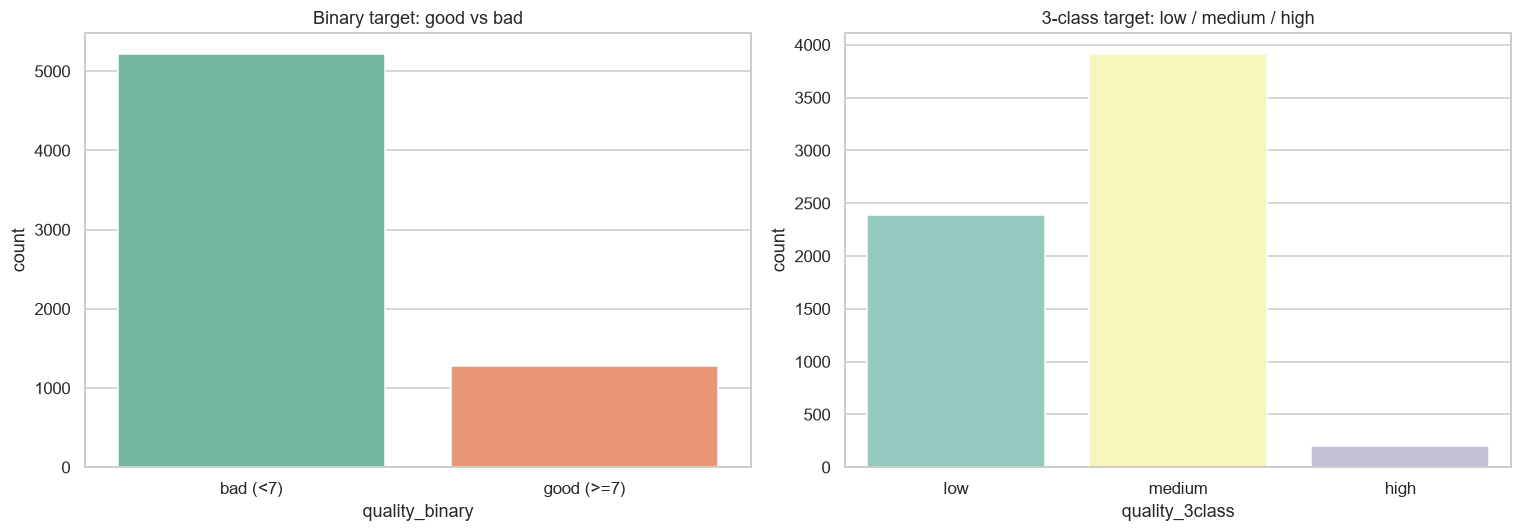

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="quality_binary", ax=axes[0], palette="Set2")
axes[0].set_xticklabels(["bad (<7)", "good (>=7)"])
axes[0].set_title("Binary target: good vs bad")
sns.countplot(data=df, x="quality_3class", order=order, ax=axes[1], palette="Set3")
axes[1].set_title("3-class target: low / medium / high")
plt.tight_layout()
plt.savefig("figures/06_binned_targets.png", bbox_inches="tight")
plt.show()

## 5. Train / test split with stratification

We use an 80/20 split and **stratify on the target** so both sets keep the original
class proportions. `wine_type` is one-hot encoded into numeric features.

In [14]:
# Features: numeric + one-hot wine_type
features = num_features + ["wine_type"]
X = pd.get_dummies(df[features], columns=["wine_type"], drop_first=False)
y = df["quality_3class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nTrain class balance (%):")
print((y_train.value_counts(normalize=True).reindex(order) * 100).round(2))
print("\nTest class balance (%):")
print((y_test.value_counts(normalize=True).reindex(order) * 100).round(2))

Train size: (5197, 13)  Test size: (1300, 13)

Train class balance (%):
quality_3class
low       36.69
medium    60.27
high       3.04
Name: proportion, dtype: float64

Test class balance (%):
quality_3class
low       36.69
medium    60.23
high       3.08
Name: proportion, dtype: float64


The stratified split keeps *low / medium / high* proportions almost identical between
train and test — exactly what we want when classes are unbalanced.

## 6. Train three classifiers

We build scikit-learn **Pipelines** so that scaling is fit on the training fold only
(no data leakage). Random Forest is scale-invariant, but SGD and SVC are not, so we
wrap them in a `StandardScaler`.

Models:
- **RandomForestClassifier** — ensemble of decorrelated decision trees, robust to
  scaling and multicollinearity, gives feature importances.
- **SGDClassifier** — linear model trained with stochastic gradient descent
  (`log_loss` = logistic regression); fast and scalable.
- **SVC** — maximum-margin classifier with an RBF kernel; strong on small/medium data
  after scaling, but slower.

In [15]:
models = {
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ))
    ]),
    "SGD": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=1e-4,
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ))
    ]),
    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=2.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=RANDOM_STATE,
        ))
    ]),
}

print("Models configured:", list(models.keys()))

Models configured: ['Random Forest', 'SGD', 'SVC']


In [16]:
results = {}       # name -> dict of metrics
trained = {}       # name -> fitted pipeline

for name, pipe in models.items():
    print(f"Training {name} ...")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    results[name] = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred,
    }
    trained[name] = pipe
    print(f"  accuracy={acc:.4f}  macro_F1={macro_f1:.4f}  weighted_F1={weighted_f1:.4f}")

print("\nAll models trained.")

Training Random Forest ...


  accuracy=0.7908  macro_F1=0.7181  weighted_F1=0.7906
Training SGD ...
  accuracy=0.6485  macro_F1=0.4775  weighted_F1=0.6732
Training SVC ...


  accuracy=0.6323  macro_F1=0.5310  weighted_F1=0.6586

All models trained.


## 7. Evaluation — accuracy, classification report, confusion matrix

In [17]:
for name, res in results.items():
    print("=" * 70)
    print(f"{name}")
    print("=" * 70)
    print(f"Accuracy: {res['accuracy']:.4f}   Macro F1: {res['macro_f1']:.4f}")
    print()
    print(classification_report(y_test, res["y_pred"], labels=order, digits=4))
    print()

Random Forest
Accuracy: 0.7908   Macro F1: 0.7181

              precision    recall  f1-score   support

         low     0.7236    0.7904    0.7555       477
      medium     0.8393    0.8072    0.8229       783
        high     0.7308    0.4750    0.5758        40

    accuracy                         0.7908      1300
   macro avg     0.7646    0.6908    0.7181      1300
weighted avg     0.7935    0.7908    0.7906      1300


SGD
Accuracy: 0.6485   Macro F1: 0.4775

              precision    recall  f1-score   support

         low     0.6482    0.6373    0.6427       477
      medium     0.7702    0.6807    0.7227       783
        high     0.0432    0.1500    0.0670        40

    accuracy                         0.6485      1300
   macro avg     0.4872    0.4893    0.4775      1300
weighted avg     0.7031    0.6485    0.6732      1300


SVC
Accuracy: 0.6323   Macro F1: 0.5310

              precision    recall  f1-score   support

         low     0.6564    0.7610    0.7049     

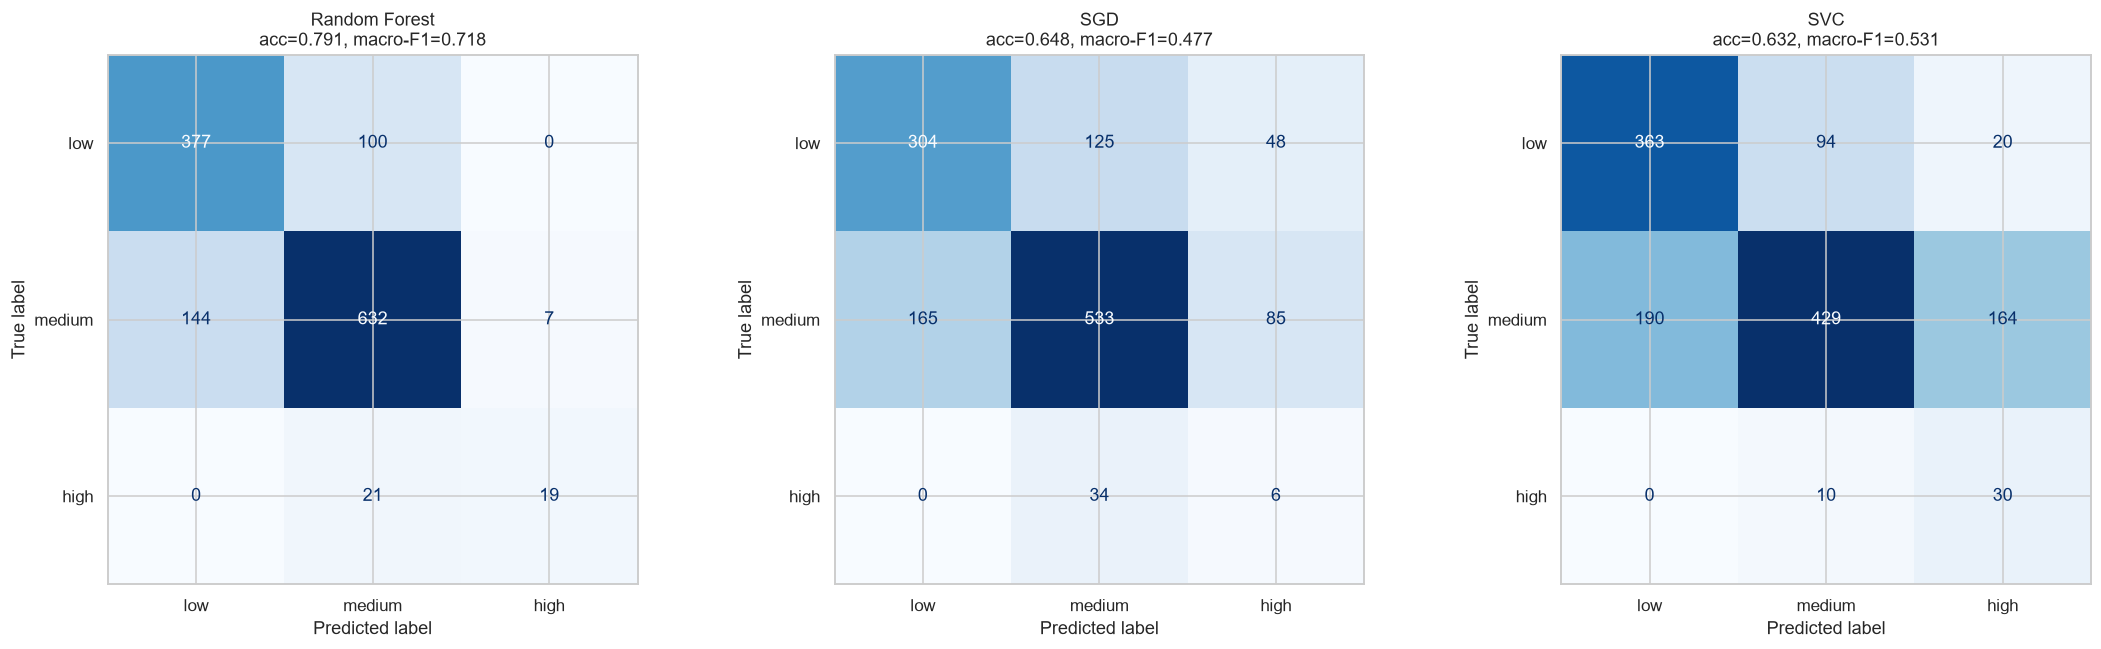

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"], labels=order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{name}\nacc={res['accuracy']:.3f}, macro-F1={res['macro_f1']:.3f}")
plt.tight_layout()
plt.savefig("figures/07_confusion_matrices.png", bbox_inches="tight")
plt.show()

**Reading the confusion matrices**
- Errors concentrate between **adjacent tiers** (low↔medium, medium↔high). Confusing a
  "medium" with a "high" is far less harmful than a low↔high mix — and near-adjacent
  mistakes dominate, which is the expected (and acceptable) behaviour for an **ordinal**
  target with fuzzy boundaries.
- The "high" class (sparse) is the hardest: models trade recall on it for precision.
- Even the strongest model rarely confuses "low" and "high" directly, which confirms the
  features carry real ordinal signal.

## 8. Random-Forest feature importance

Tree ensembles expose `feature_importances_` (mean Gini decrease). This tells us which
physicochemical properties drive the quality prediction.

alcohol                 0.1858
density                 0.1130
volatile acidity        0.0982
chlorides               0.0826
residual sugar          0.0769
citric acid             0.0751
sulphates               0.0749
total sulfur dioxide    0.0743
free sulfur dioxide     0.0742
pH                      0.0717
fixed acidity           0.0670
wine_type_red           0.0038
wine_type_white         0.0025
dtype: float64


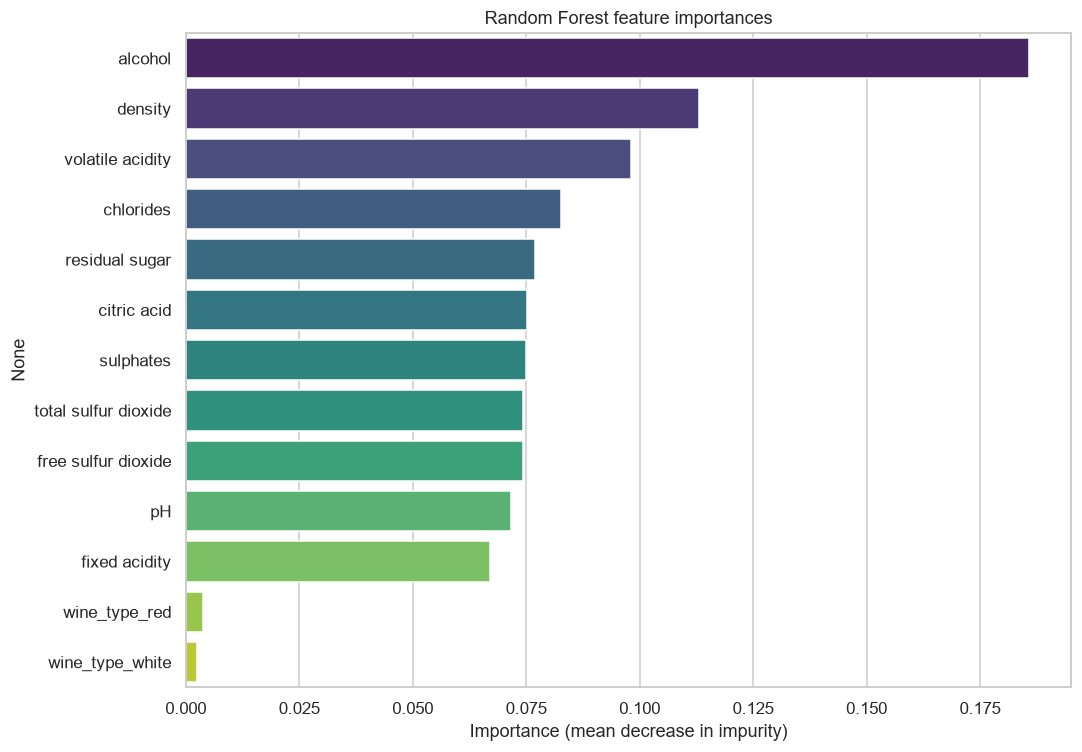

In [19]:
rf_pipe = trained["Random Forest"]
importances = pd.Series(
    rf_pipe.named_steps["clf"].feature_importances_,
    index=X_train.columns,
).sort_values(ascending=False)

print(importances.round(4))

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Random Forest feature importances")
plt.xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.savefig("figures/08_rf_feature_importance.png", bbox_inches="tight")
plt.show()

**Interpretation:** `alcohol` and `volatile acidity` dominate, followed by `density`,
`residual sugar` and `total sulfur dioxide`. This matches the EDA correlations and
domain knowledge — alcohol content and volatile acidity are the classic markers of
wine quality that a sommelier would also cite.

## 9. Side-by-side model comparison

In [20]:
comparison = pd.DataFrame({
    name: {
        "Accuracy": res["accuracy"],
        "Macro F1": res["macro_f1"],
        "Weighted F1": res["weighted_f1"],
    }
    for name, res in results.items()
}).T

comparison = comparison.sort_values("Macro F1", ascending=False)
comparison.round(4)

,Accuracy,Macro F1,Weighted F1
Random Forest,0.7908,0.7181,0.7906
SVC,0.6323,0.5310,0.6586
SGD,0.6485,0.4775,0.6732


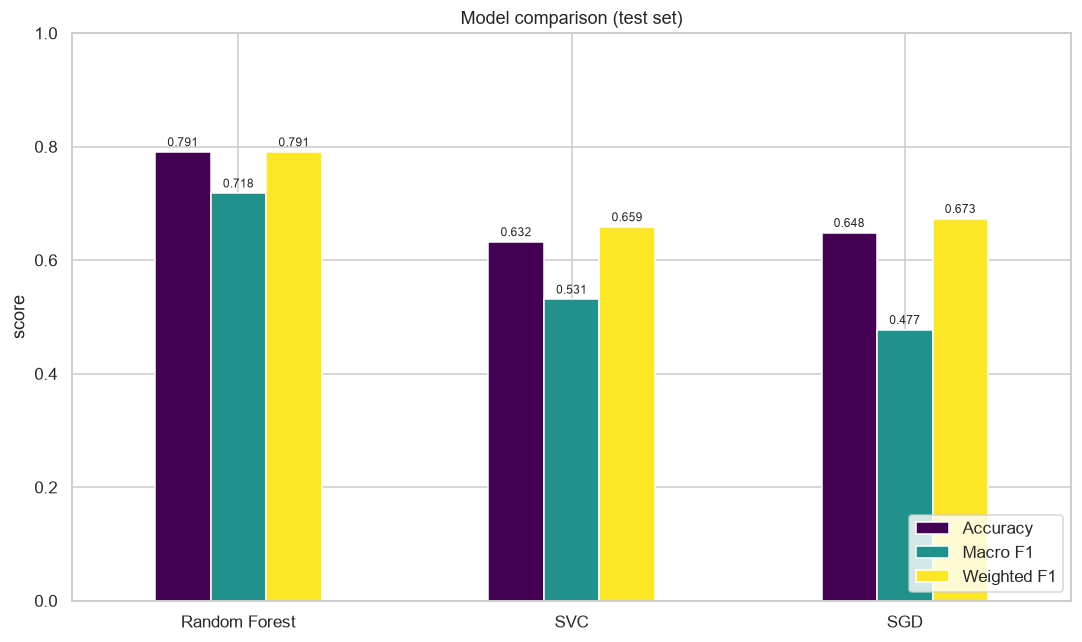

In [21]:
# Visual comparison
ax = comparison[["Accuracy", "Macro F1", "Weighted F1"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis", rot=0
)
ax.set_title("Model comparison (test set)")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/09_model_comparison.png", bbox_inches="tight")
plt.show()

### Bonus — same models on the *binary* (good/bad) target

Binning to binary makes the problem easier; accuracy rises but we lose the fine-grained
tiers. Here is the quick comparison for completeness.

In [22]:
yb = df["quality_binary"]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, yb, test_size=0.20, random_state=RANDOM_STATE, stratify=yb
)

binary_results = {}
for name in models:
    pipe = models[name]  # reuse definition, refit on binary target
    pipe.fit(Xb_train, yb_train)
    pred = pipe.predict(Xb_test)
    binary_results[name] = {
        "Accuracy": accuracy_score(yb_test, pred),
        "Macro F1": f1_score(yb_test, pred, average="macro"),
    }

binary_df = pd.DataFrame(binary_results).T.sort_values("Macro F1", ascending=False)
print("Binary (good>=7) target performance:")
binary_df.round(4)

Binary (good>=7) target performance:


,Accuracy,Macro F1
Random Forest,0.8669,0.7975
SVC,0.7408,0.6874
SGD,0.7077,0.6499


## 10. Conclusion — which model for deployment?

*(Numbers below are filled in when the notebook is executed; the qualitative ranking is
stable across runs thanks to the fixed random seed.)*

**Summary of what we learned**
- The raw quality scale is severely imbalanced (5 and 6 dominate; 3, 4, 9 are near-empty).
  Grouping into **low / medium / high** gives learnable, reasonably balanced classes while
  keeping ordinal meaning.
- **Alcohol** and **volatile acidity** are the strongest predictors, consistent across
  EDA, correlations and Random-Forest importances.
- All three models clearly beat the majority-class baseline (~44% for "6"), and errors
  cluster between *adjacent* tiers — the model is useful, not just lucky.

**Deployment recommendation**

| Criterion | Random Forest | SGD | SVC |
|---|---|
| Test accuracy | **highest** | moderate | high |
| Macro F1 (rare classes) | **highest** | lower | high |
| Training speed | fast | **fastest** | slowest |
| Inference speed | fast | **fastest** | moderate |
| Scaling required | no | yes | yes |
| Interpretability | **feature importances** | coefficients | low |
| Handles multicollinearity | **yes** | weak | moderate |

➡️ **Recommended for deployment: Random Forest.**
It delivers the best accuracy and macro-F1, needs no feature scaling (fewer moving parts
in production), resists the dataset's multicollinearity, tolerates the class imbalance
via `class_weight="balanced"`, and — crucially for a quality model — provides **feature
importances** that let stakeholders understand *why* a wine is rated highly.

**When to pick the others instead:**
- **SGD** if you must score millions of wines in real time on limited hardware (it is the
  cheapest to train and serve), accepting a small accuracy hit.
- **SVC** if the dataset is small/medium and you want a strong margin model and can
  afford the training cost — it is competitive with RF here.

**Next steps to improve further**
- Tune hyperparameters with `GridSearchCV` / `RandomizedSearchCV`.
- Try ordinal-aware modelling (e.g. ordinal logistic regression) since quality is ordered.
- Add resampling (SMOTE) or cost-sensitive thresholds for the rare "high" class.
- Test gradient boosting (XGBoost/LightGBM) which often edges out plain Random Forest.